# Load Dataset and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
GPATH = "/content/drive/My Drive/aiml/GL/git/bangalore-feb-batch-smurli/R6/NNDL_Proj 1"
DATA_FILE=GPATH+"/Churn_Modelling.csv"

In [0]:
import numpy as np
import pandas as pd


In [0]:
df1 = pd.read_csv(DATA_FILE)

In [33]:
df1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Clensing

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [0]:
df2 = df1.drop(["CustomerId", "RowNumber", "Surname"], axis=1)

In [25]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


# Data Visualization

/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


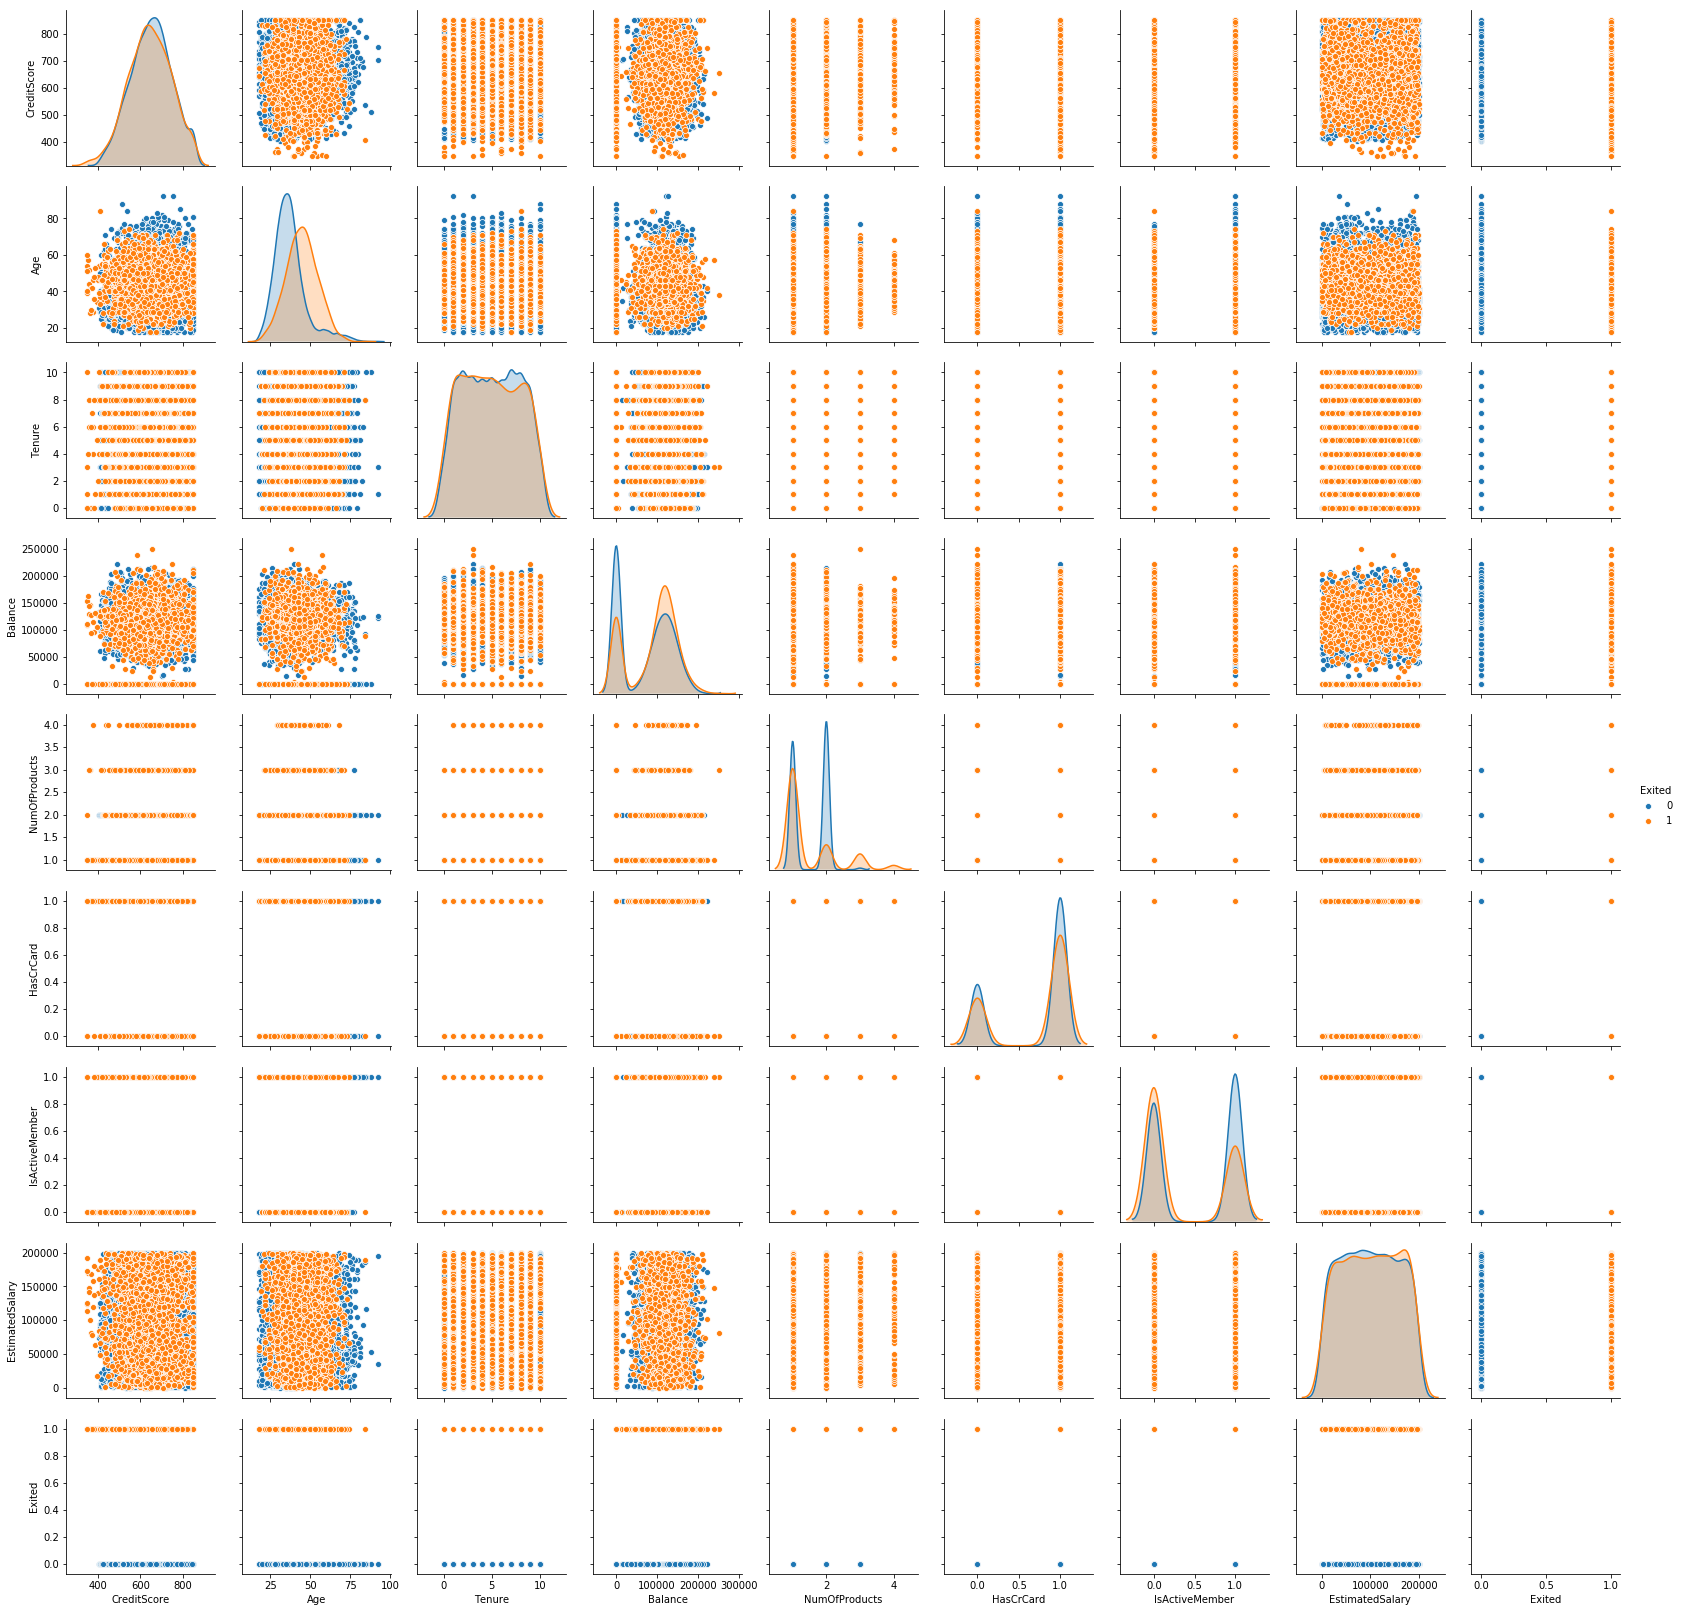

In [36]:
import seaborn as sns
sns.pairplot(df2, hue="Exited")

# Prepare Dataset

In [37]:
df = pd.get_dummies(df2, drop_first = True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [0]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape

(7000, 11)

#Define Model

In [0]:
import tensorflow.keras as keras

In [52]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(20, input_shape=(11,), activation='relu'))
model.add(keras.layers.Dense(10, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_7 (Dense)              (None, 20)                240       
_________________________________________________________________
dense_8 (Dense)              (None, 10)                210       
_________________________________________________________________
dense_9 (Dense)              (None, 1)                 11        
Total params: 461
Trainable params: 461
Non-trainable params: 0
_________________________________________________________________


In [54]:
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test),
                    epochs=100)

Train on 7000 samples, validate on 3000 samples
Epoch 1/100
7000/7000 [==============================] - 0s 58us/sample - loss: 0.3033 - acc: 0.8773 - val_loss: 0.3548 - val_acc: 0.8517
Epoch 2/100
7000/7000 [==============================] - 0s 51us/sample - loss: 0.3041 - acc: 0.8754 - val_loss: 0.3570 - val_acc: 0.8473
Epoch 3/100
7000/7000 [==============================] - 0s 52us/sample - loss: 0.3023 - acc: 0.8774 - val_loss: 0.3573 - val_acc: 0.8457
Epoch 4/100
7000/7000 [==============================] - 0s 50us/sample - loss: 0.3014 - acc: 0.8774 - val_loss: 0.3574 - val_acc: 0.8460
Epoch 5/100
7000/7000 [==============================] - 0s 52us/sample - loss: 0.3026 - acc: 0.8779 - val_loss: 0.3560 - val_acc: 0.8470
Epoch 6/100
7000/7000 [==============================] - 0s 50us/sample - loss: 0.3023 - acc: 0.8786 - val_loss: 0.3562 - val_acc: 0.8493
Epoch 7/100
7000/7000 [==============================] - 0s 51us/sample - loss: 0.3021 - acc: 0.8776 - val_loss: 0.3581 - va

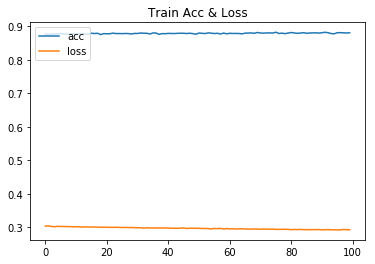

In [57]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'])
plt.plot(history.history['loss'])
plt.title("Train Acc & Loss")
plt.legend(['acc', 'loss'], loc='upper left')

plt.show()

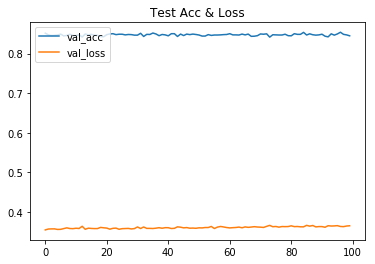

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_acc'])
plt.plot(history.history['val_loss'])
plt.title("Test Acc & Loss")
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()

### Observation
We see a training accuracy of 88% and test accuracy of 84%

In [68]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5) 

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
cm = confusion_matrix(y_test, y_pred)
print ("Confusion Matrix:\n", cm)
print ("Accuracy:", accuracy_score(y_test, y_pred))
print ("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[2245  158]
 [ 307  290]]
Accuracy: 0.845
F1 Score: 0.5550239234449761


# Optimize Model

In [96]:
activationFxn = keras.layers.Softmax()
#activationFxn = "sigmoid"

model2 = keras.models.Sequential()
model2.add(keras.layers.Dense(20, input_shape=(11,), activation=activationFxn))
model2.add(keras.layers.Dense(10, activation=activationFxn))
model2.add(keras.layers.Dense(5, activation=activationFxn))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_41 (Dense)             (None, 20)                240       
_________________________________________________________________
dense_42 (Dense)             (None, 10)                210       
_________________________________________________________________
dense_43 (Dense)             (None, 5)                 55        
_________________________________________________________________
dense_44 (Dense)             (None, 1)                 6         
Total params: 511
Trainable params: 511
Non-trainable params: 0
_________________________________________________________________


In [97]:
history = model2.fit(X_train, y_train, 
                    validation_data=(X_test, y_test),
                    epochs=100)

Train on 7000 samples, validate on 3000 samples
Epoch 1/100
7000/7000 [==============================] - 1s 106us/sample - loss: 0.6194 - acc: 0.7943 - val_loss: 0.5654 - val_acc: 0.8010
Epoch 2/100
7000/7000 [==============================] - 0s 63us/sample - loss: 0.5444 - acc: 0.7943 - val_loss: 0.5203 - val_acc: 0.8010
Epoch 3/100
7000/7000 [==============================] - 0s 60us/sample - loss: 0.5174 - acc: 0.7943 - val_loss: 0.5034 - val_acc: 0.8010
Epoch 4/100
7000/7000 [==============================] - 0s 59us/sample - loss: 0.5068 - acc: 0.7943 - val_loss: 0.4948 - val_acc: 0.8010
Epoch 5/100
7000/7000 [==============================] - 0s 59us/sample - loss: 0.4982 - acc: 0.7943 - val_loss: 0.4847 - val_acc: 0.8010
Epoch 6/100
7000/7000 [==============================] - 0s 60us/sample - loss: 0.4836 - acc: 0.7943 - val_loss: 0.4656 - val_acc: 0.8010
Epoch 7/100
7000/7000 [==============================] - 0s 59us/sample - loss: 0.4584 - acc: 0.7943 - val_loss: 0.4390 - v

In [98]:
y_pred = model2.predict(X_test)
y_pred = (y_pred > 0.5) 

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
cm = confusion_matrix(y_test, y_pred)
print ("Confusion Matrix:\n", cm)
print ("Accuracy:", accuracy_score(y_test, y_pred))
print ("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[2273  130]
 [ 310  287]]
Accuracy: 0.8533333333333334
F1 Score: 0.5660749506903354


### Observation
With "sigmoid" activation function and adding another layer the model is giving sligtly better performance in terms of f1-score, 56% vs 54% 